#Section 1

## 1. Definition of Sample and population

- Sample is portion representative of the population under study
- Population is all the entry point of a particular occurence under considerations and study

## 2. What confidence interval tell us

It tell us how confident we are with our estimated range of the population mean from the sample mean

## 3. An hypothesis

An informed assuption made about a particular phenomena which is tested to verify its accuracy

## 4. Types of hypothesis

- Null hypothesis: its a statement we are trying to disprove and is stated in the negative form. eg The lowest temperature recorded in Nairobi is not below 16 degrees
- Alternate hypothesis: a statement we accept as true if there is sufficient evidence eg The lowest temperature recorded in Nairobi is below 16 degrees

## 5. Hypothesis testing and which type is tested

Its the process of verifying the accuracy and validity of a stated assumption
We test Null hypothesis

## 6. Hypothesis testing process

1. State your hypothesis
2. Choose your alpha value
3. Perform statistical test depending on the nature of the data
4. Calculate the p-value
5. Make a decision to accept null hypothesis if P value is greater than alpha and if vice versa reject

## 7. Alpha

its the amount of error we are willing to accept as statistically insignificant

## 8. Relation between P value and alpha

If the P value is greater than alpha, there is weak evidence against the null hypothesis and we consequently accept it as true
If the P value is less than alpha, there is strong evidence against the hypothesis and we reject it

## 9. Assumptions on data for parametric test

- Data is normally distributed
- The variance is equal

##10. Test to determine normal distribution

Shapiro Wilk test for a small dataset

#Section 2

In [ ]:
import pandas as pd #initializing the dataset

athletes = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-07-27/athlete_events.csv")

##a)

- Null hypothesis - The average male olympian height is not different from the average female olympian height
- Alternate hypothesis - The average male olympian height is different from the average female olympian height

##b - d)

###Preparing the dataset

In [ ]:
maledf = athletes[athletes['Sex'] == 'M'][['Name','Height']].dropna(subset='Height').drop_duplicates(subset='Name') #extracting male heights
femaledf = athletes[athletes['Sex'] == 'F'][['Name','Height']].dropna(subset='Height').drop_duplicates(subset='Name') #extracting female

In [ ]:
maledf.Height.describe()

,Height
count,71071.000000
mean,179.439434
std,9.462859
min,127.000000
25%,173.000000
50%,180.000000
75%,185.000000
max,226.000000


In [ ]:
femaledf.Height.describe()

,Height
count,30082.000000
mean,168.931986
std,8.506362
min,127.000000
25%,163.000000
50%,169.000000
75%,174.000000
max,213.000000


###Normality test and equality of variance test

In [ ]:
from scipy.stats import shapiro

stat_m, p_m = shapiro(maledf.Height)
print(f"Male: W={stat_m:.4f}, p={p_m:.4f}")
if p_m < 0.05:
    print("male heights are NOT normally distributed")
else:
    print("male heights are consistent with normality")


stat_f, p_f = shapiro(femaledf.Height)
print(f"Female: W={stat_f:.4f}, p={p_f:.4f}")
if p_f < 0.05:
    print("female heights are NOT normally distributed")
else:
    print("female heights are consistent with normality")



Male: W=0.9967, p=0.0000
male heights are NOT normally distributed
Female: W=0.9956, p=0.0000
female heights are NOT normally distributed


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 71071.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 30082.
  res = hypotest_fun_out(*samples, **kwds)


Our sample size is very large and because Shapiro-Wilk test is very sensitive to small deviations in larger samples sizes we will do a visual follow up check

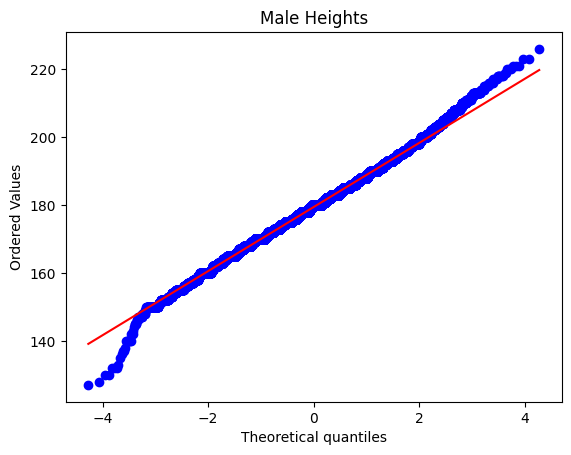

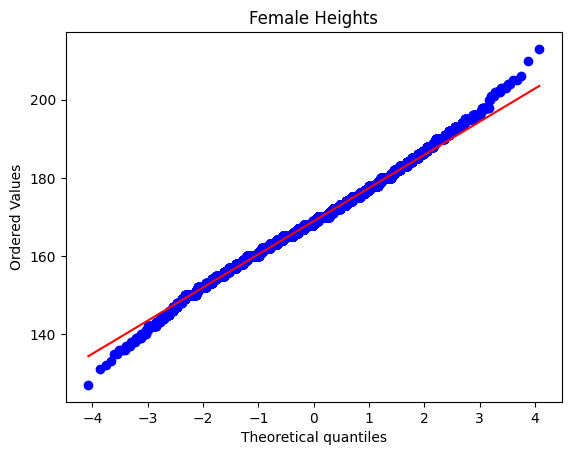

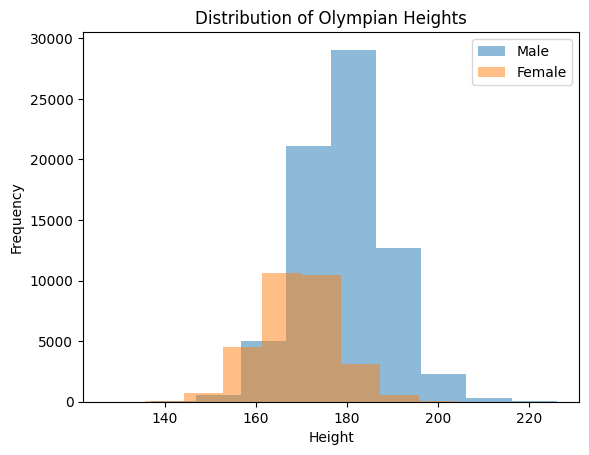

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Q-Q for male
plt.figure()
stats.probplot(maledf.Height, dist="norm", plot=plt)
plt.title("Male Heights")
plt.show()

# Q–Q for female
plt.figure()
stats.probplot(femaledf.Height, dist="norm", plot=plt)
plt.title("Female Heights")
plt.show()

#Histogram to check for normal distributions
plt.figure()
plt.hist(maledf.Height,   alpha=0.5, label='Male')
plt.hist(femaledf.Height, alpha=0.5, label='Female')
plt.xlabel('Height')
plt.ylabel('Frequency')
plt.title('Distribution of Olympian Heights')
plt.legend()
plt.show()

In [ ]:
from scipy.stats import levene

stat_levene, p_levene = levene(maledf.Height, femaledf.Height, center='median')
print(f"Levene’s test: W={stat_levene:.4f}, p={p_levene:.4f}")
if p_levene < 0.05:
    print("variances differ between groups")
else:
    print("no evidence variances differ")

Levene’s test: W=379.0410, p=0.0000
variances differ between groups


- Our data is parametric as verified by the normality test. Testing for normalcy using Shapiros test comes out negative most likely due to the size of our data. The descriptive stats and visual Q-Q test and histrogram however confirm the data is indeed normaly distributed. However the two group have different variances(our descriptive stats clearly shows the difference in std confirming the Levene test)

- We will therefore use the Welsh test.

##e & f) Statistical test and P-value

In [ ]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(maledf.Height, femaledf.Height, equal_var=False)

print(f"Welch’s t‑statistic = {t_stat:.4f}")
print(f"Welch’s p‑value     = {p_value:.60f}")

Welch’s t‑statistic = 173.5568
Welch’s p‑value     = 0.000000000000000000000000000000000000000000000000000000000000


##g)The decision

Our P value is extremely small and the t statistic being greater than 30 confirms this suggestion. Its so small that the computer mememory does not have suffient space to calculate its accuracy levels and just underflows to 0.

However P<alpha hence we reject the null hypothesis: Male and female olympians average height have a statistical difference